On récupère les tenseurs save avant

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tensors_path = '../data/tensors/lstm_tensors.npz'
data = np.load(tensors_path)

X_train_3d = data['X_train']
y_train = data['y_train']
X_test_3d = data['X_test']
y_test = data['y_test']

# Vérification rapide
print("Données chargées avec succès !")
print(f"Shape X_train 3D : {X_train_3d.shape}")
print(f"Shape X_test 3D  : {X_test_3d.shape}")

Données chargées avec succès !
Shape X_train 3D : (2804, 21, 51)
Shape X_test 3D  : (707, 21, 51)


Maintenant on veut utiliser ses tenseurs pour le deep learning, on choisit de partir sur du LSTM (Long Short-Term Memory). Mais comment fonctionne un LSTM ? Avant tout un peu d'histoire, ce modèle a été proposé par Sepp Hochreiter et Jürgen Schmidhuber en 1997. L'idée c'est que chaque unité computationelle est liée non seulement à un état cahcé h mais aussi à un état c de la cellule qui joue le rôle de mémoire. (cf. https://fr.wikipedia.org/wiki/R%C3%A9seau_de_neurones_r%C3%A9currents#Long_short-term_memory pour plus d'info)

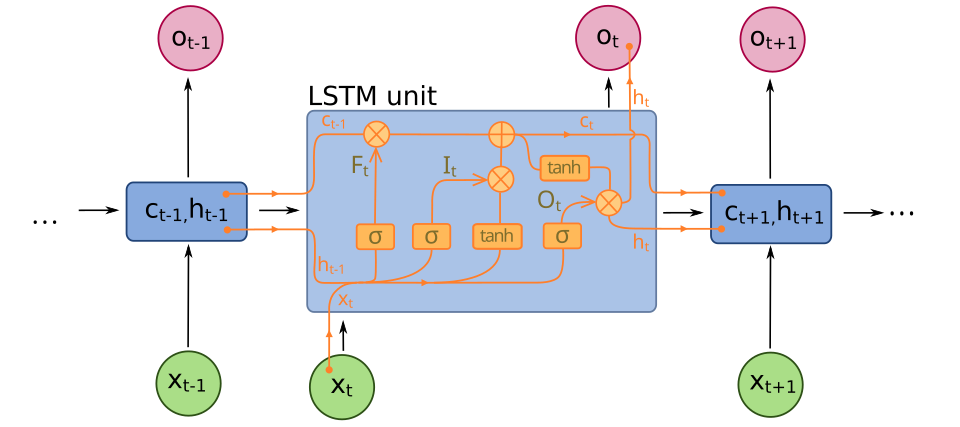

La question plus importante c'est pourquoi le LSTM et pas un autre ?
- Le MLNN (Multi-Layer Neural Network) : on perd le côté 21 jours avec 51 features (avec un ordre), on a qu'une ligne plate de 1071 variables
- Le CNN (Convolutional Neural Network 1D) : là c'est un peu mieux grâce auc filtres qui permettent de reconnaitre des formes locales, mais on perd quand même de la mémoire long-terme, il pourrait néanmoins être utile pour reconnaître figure bousière mais pas ici pour modéliser une supply chain causale avec des effets souvent plus lent
- Un modèle plus complexe (Transformers/Attention Models) : ici le problème est différent, c'est l'overfitting : si on donne 2800 jours de train avec 51 features, les données sont certes nombreuses mais pas pour ce genre qui demande un nombre énorme de données, il risque donc de faire de l'overfitting : le principe du rasoir d'Ockham (L'explication la plus simple est généralement la bonne ou Pourquoi faire compliqué quand on peut faire simple ? =>https://fr.wikipedia.org/wiki/Rasoir_d%27Ockham), la finance à un ratio Signal-sur-Bruit très important, le modèle apprend'ait donc le bruit au lieu des règles de marché (surtout avec aussi peu de données)
- Le RNN (Recurrent Neural Network) : même si le RNN a pour but de garder l'information, il ne la garde pas assez longtemps, elle se dégrade trop vite, ainsi au jour 21, on a plus la data du jour 1 (Vanishing Gradient), car à chaque étape l'information est écrasée par une fonction mathématique du type tanh
- Le LSTM :
    - il ingère les données de façon séquentielle (jour 1 ==> jour 2 ==> ... ==> jour 21), il comprend donc l'ordre
    - forget gate : chaque jour qui passse, le LSTM calcule mathématiquement, s'il doit oublier l'information passé (bruit quotidien) ou la retenir (information importante)
    - input gate : mise à jour de sa mémoire centrale (cell state : c) uniquement si la nouvelle journée apporte une information structurelle (par exemple changement de régime HMM)
    - bonne taille pour la finance : un LSTM a souvent quelques milliers de paramètres, ce qui est suffisament puissant pour trouver les relations (non-linéaires) entre les 51 features, mais aussi assez petit pour ne pas faire de l'overfitting sur les 2800 jours de données de train (surtout si on ajoute une couche de Dropout)

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

_, TIME_STEPS, NUM_FEATURES = X_train_3d.shape

# Construction du modèle LSTM
model = Sequential()
model.add(LSTM(units=32,
               activation='tanh',
               kernel_regularizer=l2(0.01),
               recurrent_dropout=0.2,
               input_shape=(TIME_STEPS, NUM_FEATURES)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid'))

# Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

c:\Dev\ChipChainReaction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,913 (42.63 KB)

 Trainable params: 10,849 (42.38 KB)

 Non-trainable params: 64 (256.00 B)

In [25]:
# Définition du ReduceLROnPlateau permettant de réduire le taux d'apprentissage si la performance sur le jeu de validation ne s'améliore pas après un certain nombre d'époques
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1)

# Définition de l'early stopping permettant d'arrêter l'entraînement si la performance sur le jeu de validation ne s'améliore pas après un certain nombre d'époques
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           verbose=1)

# Entraînement du modèle
history = model.fit(X_train_3d, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop, reduce_lr],
                    shuffle=False,  # important car ceux sont des séries temporelles, on ne veut pas mélanger l'ordre du temps
                    verbose=1)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5127 - loss: 1.5983 - val_accuracy: 0.5116 - val_loss: 1.3413 - learning_rate: 5.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5261 - loss: 1.4460 - val_accuracy: 0.5241 - val_loss: 1.2850 - learning_rate: 5.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5386 - loss: 1.3500 - val_accuracy: 0.5276 - val_loss: 1.2521 - learning_rate: 5.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5564 - loss: 1.2602 - val_accuracy: 0.5330 - val_loss: 1.2470 - learning_rate: 5.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5515 - loss: 1.1863 - val_accuracy: 0.5294 - val_loss: 1.2388 - learning_rate: 5.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5515 - loss: 1.1216 - val_accuracy: 0.5241 - val_loss: 1.2161 - learning_rate: 5.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 

Accuracy sur le jeu de test : 0.5290


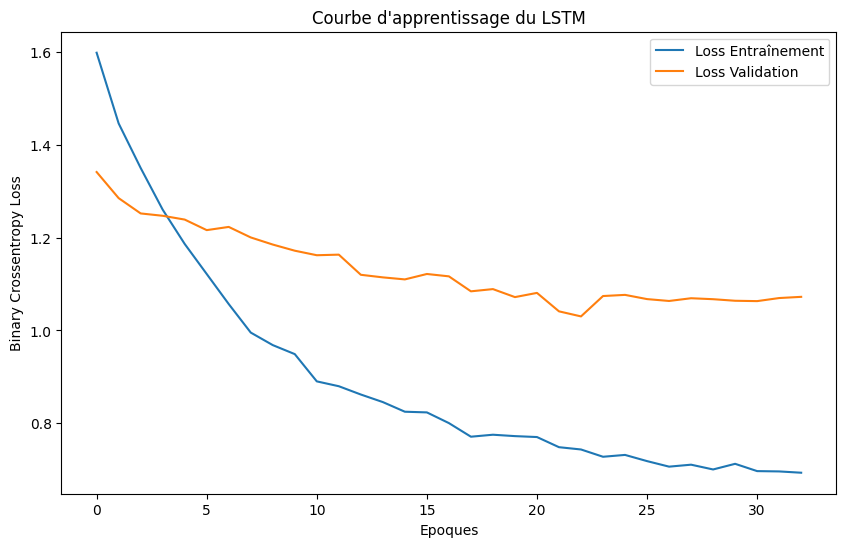

In [26]:
# Évaluation du modèle sur le jeu de test
test_loss, test_accuracy = model.evaluate(X_test_3d, y_test, verbose=0)
print(f"Accuracy sur le jeu de test : {test_accuracy:.4f}")

# Visualisation de l'historique d'entraînement
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Loss Entraînement')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title('Courbe d\'apprentissage du LSTM')
plt.ylabel('Binary Crossentropy Loss')
plt.xlabel('Epoques')
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
# On regarde la proportion de jours positifs dans la réalité
baseline_accuracy = max(np.mean(y_test), 1 - np.mean(y_test))
print(f"Accuracy de base (Si le modèle prédisait toujours la classe majoritaire) : {baseline_accuracy * 100:.2f}%")

# On regarde ce que le modèle prédit (Probabilité > 50% = 1)
y_pred_probs = model.predict(X_test_3d)
y_pred = (y_pred_probs > 0.50).astype(int)

# On affiche la matrice de confusion
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred))

Accuracy de base (Si le modèle prédisait toujours la classe majoritaire) : 55.02%
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Matrice de Confusion :
[[123 195]
 [138 251]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.47      0.39      0.42       318
           1       0.56      0.65      0.60       389

    accuracy                           0.53       707
   macro avg       0.52      0.52      0.51       707
weighted avg       0.52      0.53      0.52       707



Les résultats ne sont pas satisfaisant malgré beaucoup de chose mis en place notamment sur l'overfitting

In [31]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

_, TIME_STEPS, NUM_FEATURES = X_train_3d.shape

# 1. LA FONCTION DE CONSTRUCTION DYNAMIQUE
def build_model(hp):
    model = Sequential()
    
    # Correction du Warning Keras : Couche Input explicite
    model.add(Input(shape=(TIME_STEPS, NUM_FEATURES)))
    
    # Recherche du nombre de neurones (entre 16 et 64)
    hp_units = hp.Int('units', min_value=8, max_value=64, step=16)
    
    # Recherche de la pénalité L2 (10^-2, 10^-3 ou 10^-4)
    hp_l2 = hp.Choice('l2_penalty', values=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    
    model.add(LSTM(units=hp_units, 
                   activation='tanh',
                   kernel_regularizer=l2(hp_l2),
                   recurrent_dropout=0.2))
    
    model.add(BatchNormalization())
    
    # Recherche du taux de Dropout (0.2, 0.3, 0.4, 0.5, 0.6)
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.6, step=0.1)
    model.add(Dropout(hp_dropout))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # Recherche du Learning Rate
    hp_lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4, 5e-5, 1e-5])
    
    model.compile(optimizer=Adam(learning_rate=hp_lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. CONFIGURATION DU TUNER (Recherche Aléatoire Intelligente)
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss', # On cherche à MINIMISER l'erreur sur les données de validation
    max_trials=15,        # Le Tuner va tester 15 architectures différentes
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='chip_chain_optimization'
)

# Résumé de l'espace de recherche
tuner.search_space_summary()

# 3. LANCEMENT DE LA RECHERCHE MASSIVE
early_stop_tuner = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\n🚀 Lancement de Keras Tuner...")
tuner.search(
    X_train_3d, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_tuner],
    shuffle=False
)

# 4. RÉCUPÉRATION DU MEILLEUR MODÈLE
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\n🏆 Meilleurs Hyperparamètres trouvés :")
print(f"- Neurones : {best_hps.get('units')}")
print(f"- Dropout : {best_hps.get('dropout')}")
print(f"- Learning Rate : {best_hps.get('learning_rate')}")
print(f"- L2 Penalty : {best_hps.get('l2_penalty')}")

# On construit le modèle final avec ces hyperparamètres
best_model = tuner.hypermodel.build(best_hps)

Trial 15 Complete [00h 00m 28s]
val_loss: 0.8511557579040527

Best val_loss So Far: 0.7007574439048767
Total elapsed time: 00h 03m 15s

🏆 Meilleurs Hyperparamètres trouvés :
- Neurones : 56
- Dropout : 0.5
- Learning Rate : 5e-05
- L2 Penalty : 1e-06


Malgré une grosse recherche des meilleurs hyperparamètres (parmi ceux proposés) le système bloque à 70%, ainsi l'IA a toujours du mal à générer un avantage statistique clair sur le jour T+1, ainsi on va plutôt partir sur prédire la tendance à 5 jours pour éviter le bruit d'un seul jour.